# DQN

## 1. Librerías

In [1]:
%pip install torch "gymnasium[classic-control]" numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1.1 Evitar que el kernel se muera (conflicto entre PyTorch y matplotlib)

En Windows/Anaconda, PyTorch y matplotlib (vía numpy) cargan cada uno su propia copia de la librería OpenMP
(`libiomp5md.dll`). Al cargarse las dos, el kernel se cierra sin mostrar error.
Esta celda debe ejecutarse **siempre primero**, justo después de reiniciar el kernel.

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import matplotlib
import matplotlib.pyplot as plt

## 2. Código DQN

In [3]:
"""
Deep Q-Network (DQN) implementation in PyTorch.

This module intentionally avoids high-level RL libraries so every piece of
the algorithm is visible and editable for learning purposes.

Key components:
  - QNetwork     : a small fully-connected network that maps state -> Q(s,a)
  - ReplayBuffer : stores (s, a, r, s', terminated) transitions for replay
  - DQNAgent     : the training loop, epsilon-greedy policy, target-net sync
"""
import random
from collections import deque
from pathlib import Path
from typing import Self

import gymnasium as gym
import numpy as np
import torch
from torch import nn, optim

# ── Neural network ────────────────────────────────────────────────────


class QNetwork(nn.Module):
    """EXERCISE 2a: the network that maps a state to one Q-value per action.

    Build a small fully-connected net:

        state_dim -> hidden -> hidden -> action_dim

    with a ReLU after each hidden layer. There is NO activation on the output
    layer: these are Q-values (here they are all negative), not probabilities.
    """

    def __init__(self, state_dim: int, action_dim: int, hidden: int = 128) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(state_dim, hidden),  
            nn.ReLU(),
            nn.Linear(hidden, hidden),  
            nn.ReLU(),
            nn.Linear(hidden, action_dim), 
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)


# ── Replay buffer ────────────────────────────────────────────────────


class ReplayBuffer:
    """Fixed-size FIFO buffer that stores transitions for experience replay."""

    def __init__(self, capacity: int = 100_000) -> None:
        self.buffer: deque[tuple] = deque(maxlen=capacity)

    def push(
        self,
        state: np.ndarray,
        action: int,
        reward: float,
        next_state: np.ndarray,
        terminated: bool,
    ) -> None:
        self.buffer.append((state, action, reward, next_state, terminated))

    def sample(self, batch_size: int) -> list[tuple]:
        return random.sample(self.buffer, batch_size)

    def __len__(self) -> int:
        return len(self.buffer)


# ── Agent ─────────────────────────────────────────────────────────────


class DQNAgent:
    """
    Deep Q-Network agent implemented from scratch.

    Hyperparameters are intentionally exposed as constructor args so you
    can experiment with them directly.
    """

    def __init__(
        self,
        env_id: str,
        *,
        lr: float = 1e-3,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.01,
        epsilon_decay: float = 0.995,
        batch_size: int = 64,
        buffer_capacity: int = 100_000,
        target_update_freq: int = 10,
        hidden: int = 128,
    ) -> None:
        self.env_id = env_id
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.buffer_capacity = buffer_capacity
        self.target_update_freq = target_update_freq
        self.hidden = hidden
        self.training_episodes = 0

        env = gym.make(env_id)
        self.state_dim = int(env.observation_space.shape[0])  # type: ignore[index]
        self.action_dim = int(env.action_space.n)  # type: ignore[attr-defined]
        env.close()

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.q_net = QNetwork(self.state_dim, self.action_dim, hidden).to(self.device)
        self.target_net = QNetwork(self.state_dim, self.action_dim, hidden).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        self.buffer = ReplayBuffer(buffer_capacity)

    # ── policy ────────────────────────────────────────────────────────

    def select_action(self, state: np.ndarray, *, deterministic: bool = False) -> int:

        if not deterministic and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        with torch.no_grad():
            t = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            return int(self.q_net(t).argmax(dim=1).item())

    def predict(self, obs: np.ndarray, *, deterministic: bool = True) -> tuple[int, None]:
        return self.select_action(obs, deterministic=deterministic), None

    # ── learning step ─────────────────────────────────────────────────

    def _tensor(self, x, dtype=torch.float32) -> torch.Tensor:
        return torch.as_tensor(np.array(x), dtype=dtype, device=self.device)

    def _learn(self) -> float:
        """Sample a mini-batch from the buffer and take one gradient step.

        Returns the batch loss value.
        """
        if len(self.buffer) < self.batch_size:
            return 0.0

        batch = self.buffer.sample(self.batch_size)
        states, actions, rewards, next_states, terminateds = zip(*batch)

        states_t = self._tensor(states)
        actions_t = self._tensor(actions, torch.int64).unsqueeze(1)
        rewards_t = self._tensor(rewards).unsqueeze(1)
        next_states_t = self._tensor(next_states)
        terminateds_t = self._tensor(terminateds).unsqueeze(1)

        # EXERCISE 2b:the DQN learning step.

        # 1:  current_q
        all_current_values = self.q_net(states_t)           
        current_q = all_current_values.gather(1, actions_t) 

        # 2-3. next_q - target_q
        with torch.no_grad():
            all_next_values = self.target_net(next_states_t)          # forma (batch, 3)
            next_q = all_next_values.max(dim=1, keepdim=True).values  # forma (batch, 1)
            # si el episodio terminó de verdad (llegó a la bandera), el futuro vale 0
            target_q = rewards_t + self.gamma * next_q * (1.0 - terminateds_t)

        # Paso 4
        loss = self.loss_fn(current_q, target_q)
        self.optimizer.zero_grad()   # borrar los gradientes anteriores
        loss.backward()              # calcular los gradientes nuevos
        self.optimizer.step()        # mover los pesos de la red

        return loss.item()

    # ── training loop ─────────────────────────────────────────────────

    def train(self, total_episodes: int = 500, log_interval: int = 10) -> list[float]:
        env = gym.make(self.env_id)
        rewards_history: list[float] = []

        for episode in range(1, total_episodes + 1):
            obs, _ = env.reset()
            total_reward = 0.0
            done = False

            while not done:
                action = self.select_action(obs)
                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated

                # Store `terminated`, not `done`: hitting the 200-step time
                # limit is not a real terminal state, so we must keep
                # bootstrapping through it.
                self.buffer.push(obs, action, float(reward), next_obs, terminated)
                self._learn()

                obs = next_obs
                total_reward += reward

            self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
            self.training_episodes += 1
            rewards_history.append(total_reward)

            if episode % self.target_update_freq == 0:
                self.target_net.load_state_dict(self.q_net.state_dict())

            if episode % log_interval == 0:
                avg = np.mean(rewards_history[-log_interval:])
                print(
                    f"Episode {episode}/{total_episodes} | "
                    f"Avg Reward: {avg:.2f} | "
                    f"Epsilon: {self.epsilon:.4f} | "
                    f"Buffer: {len(self.buffer)}"
                )

        env.close()
        return rewards_history

    # ── persistence ───────────────────────────────────────────────────

    _HPARAMS = (
        "env_id",
        "lr",
        "gamma",
        "epsilon_end",
        "epsilon_decay",
        "batch_size",
        "buffer_capacity",
        "target_update_freq",
        "hidden",
    )

    def save(self, path: Path) -> None:
        path.parent.mkdir(parents=True, exist_ok=True)
        data = {k: getattr(self, k) for k in self._HPARAMS}
        data["q_net_state"] = self.q_net.state_dict()
        data["optimizer_state"] = self.optimizer.state_dict()
        data["epsilon"] = self.epsilon
        data["training_episodes"] = self.training_episodes
        torch.save(data, path)
        print(f"Saved DQN agent to {path}")

    @classmethod
    def load(cls, path: Path) -> Self:
        data = torch.load(path, weights_only=False)
        agent = cls(
            data["env_id"],
            epsilon_start=data["epsilon"],
            **{k: data[k] for k in cls._HPARAMS if k != "env_id"},
        )
        # The target net starts as a copy of the online net; it re-syncs during
        # training anyway, so there is no need to persist it separately.
        agent.q_net.load_state_dict(data["q_net_state"])
        agent.target_net.load_state_dict(data["q_net_state"])
        agent.optimizer.load_state_dict(data["optimizer_state"])
        agent.training_episodes = data["training_episodes"]
        return agent

    def info(self) -> str:
        params = sum(p.numel() for p in self.q_net.parameters())
        return (
            f"DQN agent for {self.env_id}\n"
            f"  Episodes trained  : {self.training_episodes}\n"
            f"  Network params    : {params:,}\n"
            f"  Epsilon           : {self.epsilon:.4f}\n"
            f"  LR / Gamma        : {self.lr} / {self.gamma}\n"
            f"  Batch size        : {self.batch_size}\n"
            f"  Target update     : every {self.target_update_freq} episodes\n"
            f"  Device            : {self.device}"
        )

## 3. Arquitectura de la red

In [4]:
agent = DQNAgent("MountainCar-v0")
environment = gym.make("MountainCar-v0")

list_of_states = []
for sample_number in range(5):
    random_state = environment.observation_space.sample()
    list_of_states.append(random_state)

states_tensor = torch.as_tensor(np.array(list_of_states), dtype=torch.float32)
output_values = agent.q_net(states_tensor)

print("Forma de la salida:", output_values.shape)
print(output_values)

Forma de la salida: torch.Size([5, 3])
tensor([[-0.0246, -0.0602,  0.0227],
        [-0.0287, -0.0608,  0.0200],
        [-0.0349, -0.0508,  0.0131],
        [-0.0272, -0.0636,  0.0231],
        [-0.0407, -0.0897,  0.0228]], grad_fn=<AddmmBackward0>)


## 4. Prueba con 20 episodios

In [5]:
short_test_agent = DQNAgent("MountainCar-v0")
short_test_rewards = short_test_agent.train(total_episodes=20, log_interval=5)

Episode 5/20 | Avg Reward: -200.00 | Epsilon: 0.9752 | Buffer: 1000
Episode 10/20 | Avg Reward: -200.00 | Epsilon: 0.9511 | Buffer: 2000
Episode 15/20 | Avg Reward: -200.00 | Epsilon: 0.9276 | Buffer: 3000
Episode 20/20 | Avg Reward: -200.00 | Epsilon: 0.9046 | Buffer: 4000


## 5. Prueba en CartPole

In [6]:
cartpole_agent = DQNAgent("CartPole-v1", epsilon_decay=0.98)
cartpole_rewards = cartpole_agent.train(total_episodes=200, log_interval=25)

Episode 25/200 | Avg Reward: 20.68 | Epsilon: 0.6035 | Buffer: 517
Episode 50/200 | Avg Reward: 57.00 | Epsilon: 0.3642 | Buffer: 1942
Episode 75/200 | Avg Reward: 166.24 | Epsilon: 0.2198 | Buffer: 6098
Episode 100/200 | Avg Reward: 172.60 | Epsilon: 0.1326 | Buffer: 10413
Episode 125/200 | Avg Reward: 140.16 | Epsilon: 0.0800 | Buffer: 13917
Episode 150/200 | Avg Reward: 134.68 | Epsilon: 0.0483 | Buffer: 17284
Episode 175/200 | Avg Reward: 147.92 | Epsilon: 0.0291 | Buffer: 20982
Episode 200/200 | Avg Reward: 178.56 | Epsilon: 0.0176 | Buffer: 25446


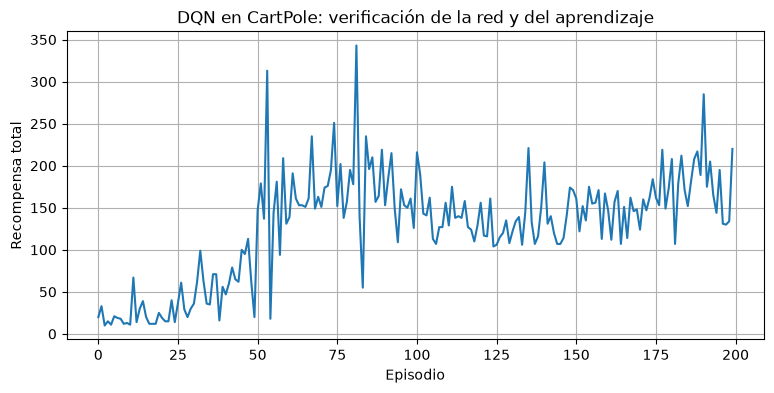

In [11]:
plt.figure(figsize=(9, 4))
plt.plot(cartpole_rewards)
plt.xlabel("Episodio")
plt.ylabel("Recompensa total")
plt.title("DQN en CartPole: verificación de la red y del aprendizaje")
plt.grid(True)
plt.show()

## 6. MountainCar con 1000 episodios

In [8]:
mountaincar_agent = DQNAgent("MountainCar-v0")
mountaincar_rewards = mountaincar_agent.train(total_episodes=1000, log_interval=50)

Episode 50/1000 | Avg Reward: -200.00 | Epsilon: 0.7783 | Buffer: 10000
Episode 100/1000 | Avg Reward: -200.00 | Epsilon: 0.6058 | Buffer: 20000
Episode 150/1000 | Avg Reward: -200.00 | Epsilon: 0.4715 | Buffer: 30000
Episode 200/1000 | Avg Reward: -200.00 | Epsilon: 0.3670 | Buffer: 40000
Episode 250/1000 | Avg Reward: -200.00 | Epsilon: 0.2856 | Buffer: 50000
Episode 300/1000 | Avg Reward: -200.00 | Epsilon: 0.2223 | Buffer: 60000
Episode 350/1000 | Avg Reward: -200.00 | Epsilon: 0.1730 | Buffer: 70000
Episode 400/1000 | Avg Reward: -200.00 | Epsilon: 0.1347 | Buffer: 80000
Episode 450/1000 | Avg Reward: -200.00 | Epsilon: 0.1048 | Buffer: 90000
Episode 500/1000 | Avg Reward: -200.00 | Epsilon: 0.0816 | Buffer: 100000
Episode 550/1000 | Avg Reward: -200.00 | Epsilon: 0.0635 | Buffer: 100000
Episode 600/1000 | Avg Reward: -200.00 | Epsilon: 0.0494 | Buffer: 100000
Episode 650/1000 | Avg Reward: -200.00 | Epsilon: 0.0385 | Buffer: 100000
Episode 700/1000 | Avg Reward: -200.00 | Epsilon

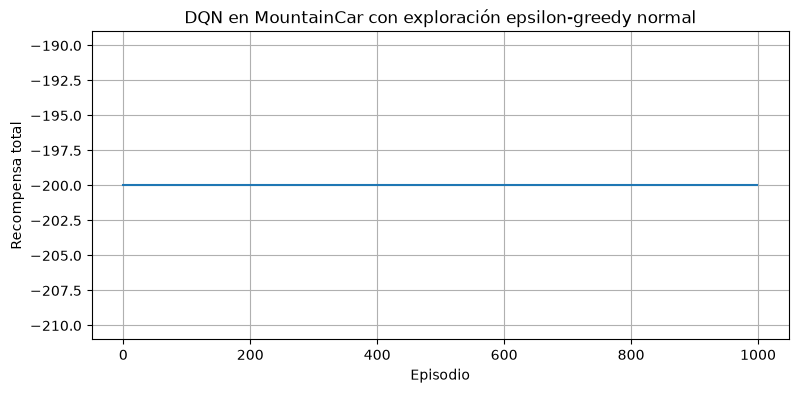

Episodios que llegaron a la bandera: 0 de 1000


In [12]:
plt.figure(figsize=(9, 4))
plt.plot(mountaincar_rewards)
plt.xlabel("Episodio")
plt.ylabel("Recompensa total")
plt.title("DQN en MountainCar con exploración epsilon-greedy normal")
plt.grid(True)
plt.show()

episodes_that_reached_the_flag = 0
for episode_reward in mountaincar_rewards:
    if episode_reward > -200:
        episodes_that_reached_the_flag = episodes_that_reached_the_flag + 1

print("Episodios que llegaron a la bandera:", episodes_that_reached_the_flag, "de", len(mountaincar_rewards))

## 7. Resultados

In [10]:
list_of_random_states = []
for sample_number in range(200):
    list_of_random_states.append(environment.observation_space.sample())

random_states_tensor = torch.as_tensor(np.array(list_of_random_states), dtype=torch.float32)

with torch.no_grad():
    q_values = mountaincar_agent.q_net(random_states_tensor).numpy()

average_q_value = q_values.mean()
difference_between_actions = np.abs(q_values.max(axis=1) - q_values.min(axis=1)).mean()

print("Promedio de los valores Q:", round(float(average_q_value), 3))
print("Diferencia promedio entre la mejor y la peor acción:", round(float(difference_between_actions), 4))

Promedio de los valores Q: -63.526
Diferencia promedio entre la mejor y la peor acción: 0.008


## 8. Hiperparámetros usados

| Hiperparámetro | Valor |
|---|---|
| Capas ocultas | 2 capas de 128 neuronas, con ReLU |
| Learning rate | 0.001 (Adam) |
| gamma | 0.99 |
| Replay buffer | 100.000 transiciones |
| Batch | 64 |
| Actualización de la target network | cada 10 episodios |
| Epsilon | de 1.0 a 0.01, con decaimiento de 0.995 por episodio |
| Función de pérdida | MSE |

## 9. Resultados obtenidos

| Prueba | Resultado |
|---|---|
| Forma de la salida de la red | `torch.Size([5, 3])` (correcta) |
| Prueba corta en MountainCar (20 episodios) | corre sin errores, recompensa -200 |
| CartPole-v1 (200 episodios) | recompensa promedio de 20.68 (episodios 1-25) a 178.56 (episodios 176-200) |
| MountainCar-v0 (1000 episodios) | recompensa -200 en todos los episodios, 0 de 1000 llegaron a la bandera |
| Promedio de los valores Q (MountainCar) | -63.53 |
| Diferencia promedio entre la mejor y la peor acción | 0.008 |

## 10. Conclusión

- En MountainCar el agente no aprendió. En los 1000 episodios nunca llegó a la bandera. Por eso solo recibió -1 en cada paso y nunca vio una recompensa diferente.

- La red le da casi el mismo valor Q en las tres acciones (la diferencia es de solo 0.008). Es decir, para la red da igual ir a la izquierda, a la derecha o no hacer nada ya que como nunca llegó a la meta, nada de lo que hizo le dio un mejor resultado.

- Para subir la montaña, el carro tiene que empujar muchas veces seguidas hacia el mismo lado. Pero al explorar, el agente elige una acción al azar en cada paso, así que casi nunca repite la misma varias veces.
